In [4]:
import pandas as pd # for data analysis
import numpy as np
import seaborn as sns # for statistical data visulization
import matplotlib.pyplot as plt   #for data visualization and graphical plotting
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer #

import nltk
nltk.download("all")
import re
from nltk.corpus import stopwords            #to filterout useless data
from nltk.corpus import stopwords

from sklearn.model_selection import cross_val_score, GridSearchCV

#Machine_Learning_Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package basque_grammars to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping grammars/basque_grammars.zip.
[nltk_data]    | Downloading package bcp47 to /root/nltk_data...
[nltk_data]    | Downloading package biocreative_ppi to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   U

## Scrapping

In [ ]:
!pip install tweety-ns
!pip install https://github.com/mahrtayyab/tweety/archive/main.zip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.9/75.9 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 5.2 MB/s eta 0:00:00
     - 85.1 kB 3.0 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from tweety import Twitter

app = Twitter("session")

all_tweets = app.get_tweets("loassbaddie")
for tweet in all_tweets:
    print(tweet.text)

saying ‘not in my reality, NEXT’ when u see/hear something u dont like gon eat every time idk
once you start smiling at his texts, KEEP assuming that its a daily occurence and that ur gonna get even more giddy at his texts
me seeing all my desires manifest, no exceptions https://t.co/cy4vKIBxna
https://t.co/qx49w63xoy
how i been feeling ever since i discovered the law https://t.co/K6rAGeko5e
https://t.co/WcHpRgztfd
‘idk what my sp is thinking..’ now what if i told u theyre literally thinking what u assume theyre thinking https://t.co/NwJ5pJ9Lry
https://t.co/mJfSL8OQ8O
the rules of manifesting: 
- come up w one or multiple desires 
- assume that theyre yours 
- persist in that assumption NO MATTER what 
- enjoy them in the physical world
REMINDERRRRRRR https://t.co/YM8xQqXfmy
was reading dinosaur philosophy and this template is so loass coded🫶🏼 https://t.co/8o1ppFdr0r
talking to ppl who r not into the loass has become so irking like fuck u and ur limiting beliefs😭
anyone who sees this t

In [ ]:
import csv
from tweety import Twitter

#  fetch tweets and save to CSV File
def save_tweets_to_csv(username, csv_filename):
    app = Twitter("session")

    all_tweets = app.get_tweets(username)

    # Open a CSV file in write mode
    with open(csv_filename, 'w', newline='', encoding='utf-8') as csvfile:
        csv_writer = csv.writer(csvfile)

        #  header row
        csv_writer.writerow(['ID', 'Author ID', 'Username', 'Name', 'Verified', 'Created On', 'Tweet Text'])

        # Write tweet data to CSV
        for tweet in all_tweets:
            tweet_id = tweet.id
            author_id = tweet.author.id
            username = tweet.author.username
            name = tweet.author.name
            verified = tweet.author.verified
            created_on = tweet.created_on
            tweet_text = tweet.text

            # Write a row for each tweet
            csv_writer.writerow([tweet_id, author_id, username, name, verified, created_on, tweet_text])

# Specify the username and CSV file name
username = "loassbaddie"
csv_filename = "loassbaddie2.csv"

# save tweets to the CSV file
save_tweets_to_csv(username, csv_filename)

In [ ]:
import pandas as pd
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Load the CSV file
df = pd.read_csv('/content/loassbaddie2.csv')

# Load the pre-trained model and tokenizer
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name)

# Classify each tweet and assign the labels
labels = []
for tweet in df['Tweet Text']:
    # Tokenize the tweet
    inputs = tokenizer.encode_plus(
        tweet,
        add_special_tokens=True,
        truncation=True,
        max_length=512,
        padding='max_length',
        return_tensors='pt'
    )

    # Perform the classification
    outputs = model(**inputs)
    predicted_label = torch.argmax(outputs.logits, dim=1).item()
    labels.append(predicted_label)

# Update the 'class' column in the DataFrame
df['class'] = labels

# Map the class labels to  'offensive_language', 'not'
class_mapping = {
    0: 'Not offensive',
    1: 'Offensive_language',

}
df['class'] = df['class'].map(class_mapping)

# Save the updated DataFrame to the CSV file
df.to_csv('_labeledloassbaddie2_tweets.csv.csv', index=False)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Importing dataset

In [5]:
df = pd.read_csv("/content/_labeledloassbaddie2_tweets.csv (1).csv")
df.head()

,ID,Author ID,Username,Name,Verified,Created On,Tweet Text,class
0,1731444071124672589,1729893285580197888,loassbaddie,k,False,2023-12-03 22:43:29+00:00,REMINDERRRRRRR https://t.co/YM8xQqXfmy,not
1,1737804852871229619,1729893285580197888,loassbaddie,k,False,2023-12-21 11:58:58+00:00,anyone who sees this tweet is getting their de...,not
2,1733181978264863038,1729893285580197888,loassbaddie,k,False,2023-12-08 17:49:19+00:00,KEEP PERSISTINGGGGG whether its staying in the...,not
3,1733985734611157236,1729893285580197888,loassbaddie,k,False,2023-12-10 23:03:09+00:00,"checking ur tl and its just ppl affirming, suc...",not
4,1737200977751531803,1729893285580197888,loassbaddie,k,False,2023-12-19 19:59:23+00:00,"the more u persist in the new story, the close...",offensive_language


## Data Cleaning and Preprocessing

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          99 non-null     int64 
 1   Author ID   99 non-null     int64 
 2   Username    99 non-null     object
 3   Name        99 non-null     object
 4   Verified    99 non-null     bool  
 5   Created On  99 non-null     object
 6   Tweet Text  99 non-null     object
 7   class       99 non-null     object
dtypes: bool(1), int64(2), object(5)
memory usage: 5.6+ KB


In [7]:
df

,ID,Author ID,Username,Name,Verified,Created On,Tweet Text,class
0,1731444071124672589,1729893285580197888,loassbaddie,k,False,2023-12-03 22:43:29+00:00,REMINDERRRRRRR https://t.co/YM8xQqXfmy,not
1,1737804852871229619,1729893285580197888,loassbaddie,k,False,2023-12-21 11:58:58+00:00,anyone who sees this tweet is getting their de...,not
2,1733181978264863038,1729893285580197888,loassbaddie,k,False,2023-12-08 17:49:19+00:00,KEEP PERSISTINGGGGG whether its staying in the...,not
3,1733985734611157236,1729893285580197888,loassbaddie,k,False,2023-12-10 23:03:09+00:00,"checking ur tl and its just ppl affirming, suc...",not
4,1737200977751531803,1729893285580197888,loassbaddie,k,False,2023-12-19 19:59:23+00:00,"the more u persist in the new story, the close...",offensive_language
...,...,...,...,...,...,...,...,...
94,1731664625123340394,1729893285580197888,loassbaddie,k,False,2023-12-04 13:19:54+00:00,listening to my affirmations while i clean the...,not
95,1732183127043239990,1729893285580197888,loassbaddie,k,False,2023-12-05 23:40:14+00:00,@inbarbad0s like that account is funny but so ...,not
96,1731352069053780276,1729893285580197888,loassbaddie,k,False,2023-12-03 16:37:54+00:00,@blumusing as u should cus its literally the o...,not
97,1731638929768522018,1729893285580197888,loassbaddie,k,False,2023-12-04 11:37:47+00:00,ayoooo loa twitter r we living in the 4d and a...,offensive_language


In [8]:
df.shape

(99, 8)

In [9]:
df.describe()

,ID,Author ID
count,9.900000e+01,9.900000e+01
mean,1.733943e+18,1.729893e+18
std,2.335925e+15,2.573028e+02
min,1.731063e+18,1.729893e+18
25%,1.731895e+18,1.729893e+18
50%,1.733240e+18,1.729893e+18
75%,1.735020e+18,1.729893e+18
max,1.739355e+18,1.729893e+18


In [10]:
df.isna().sum()

ID            0
Author ID     0
Username      0
Name          0
Verified      0
Created On    0
Tweet Text    0
class         0
dtype: int64

In [11]:
# Check missing values in our 'Tweet Text' column
missing_values = df['Tweet Text'].isnull().sum()
print(f"Number of missing values in 'Tweet Text': {missing_values}")

# Display rows with missing values in our 'Tweet Text' column
missing_rows = df[df['Tweet Text'].isnull()]
print("Rows with missing values in 'Tweet Text':")
print(missing_rows)

Number of missing values in 'Tweet Text': 0
Rows with missing values in 'Tweet Text':
Empty DataFrame
Columns: [ID, Author ID, Username, Name, Verified, Created On, Tweet Text, class]
Index: []


In [12]:
duplicated = df.duplicated("Tweet Text").sum()
if duplicated:
  print("duplicates rows in dataset are : {}".format(duplicated))
else:
  print("dataset contains no duplicated rows")

dataset contains no duplicated rows


In [13]:
corpus = list(df['Tweet Text'])  # Creating the corpus from 'Tweet Text' column

# Creating the bag of words representation
vectorizer = CountVectorizer()  # Initialize CountVectorizer
X = vectorizer.fit_transform(corpus)  # Transform text to a bag of words matrix

# Printing the vocabulary and bag of words matrix
print("Vocabulary:")
print(vectorizer.get_feature_names_out())  # Print the vocabulary (unique words)
print("\nBag of Words Matrix:")
print(X.toarray())  # Print the bag of words matrix (occurrence of words in each document)


Vocabulary:
['10' '2024' '333blessed_' '3d' '4d' '4gcpbib41u' '7vkxw6dzat'
 '8pdixbk9wi' 'ab' 'abruvpmffz' 'accepting' 'account' 'across'
 'adoressssss' 'af' 'affirm' 'affirmation' 'affirmations' 'affirming'
 'after' 'again' 'aint' 'all' 'almost' 'already' 'also' 'always' 'am'
 'amazing' 'an' 'and' 'animals' 'another' 'answer' 'any' 'anymore'
 'anyone' 'anyways' 'approach' 'archimedes' 'are' 'artists' 'as'
 'ascertainable' 'ask' 'askfirmations' 'aspect' 'ass' 'assume' 'assuming'
 'assumption' 'astrology' 'at' 'attention' 'automatic' 'average' 'aware'
 'away' 'ayoooo' 'back' 'bad' 'bc' 'bcus' 'be' 'beautiful' 'became'
 'become' 'becoming' 'been' 'before' 'being' 'belief' 'beliefs' 'believe'
 'believing' 'best' 'bet' 'bf' 'birds' 'bit' 'bitch' 'bitches' 'blumusing'
 'blurry' 'boom' 'boycott' 'brain' 'brands' 'breathing' 'bro' 'bruh' 'but'
 'by' 'can' 'cannot' 'cant' 'cause' 'change' 'chased' 'chat' 'checking'
 'cherished' 'claim' 'clean' 'closer' 'co' 'coaches' 'coded' 'come'
 'coming' '

Show Samples of texts to find out required preprocessing steps

In [14]:
for i in range(5):
  print(i,df['Tweet Text'][i])

0 REMINDERRRRRRR https://t.co/YM8xQqXfmy
1 anyone who sees this tweet is getting their desires this week, believe it!
2 KEEP PERSISTINGGGGG whether its staying in the state, ignoring the 3d, affirming, vizualizing, doing ‘nothing’ but knowing its coming, whatever, keep persisting its yours!!!!!!
3 checking ur tl and its just ppl affirming, success stories, informative tweets, and reminders i love it here
4 the more u persist in the new story, the closer u get to ur desire reflecting in the 3d and then BOOM, all of the sudden u have not only in the 4d but also physically


Remove any characters not found in the alphabet.
Make every character lowercase.
Split stings into substrings.

In [15]:
txt = []
corpus = list(df['Tweet Text'])
for i in range(len(corpus)):
    r = re.sub('[^a-zA-Z]', ' ', corpus[i])
    r = r.lower()
    r = r.split()
    r = ' '.join(r)
    txt.append(r)
df['Tweet Text'] = txt
df['Tweet Text'].head()

0                 reminderrrrrrr https t co ym xqqxfmy
1    anyone who sees this tweet is getting their de...
2    keep persistinggggg whether its staying in the...
3    checking ur tl and its just ppl affirming succ...
4    the more u persist in the new story the closer...
Name: Tweet Text, dtype: object

In [16]:
# Save Our modified DataFrame to a new CSV file
df.to_csv('filtered_data.csv', index=False)

# Display confirmation message that the filtered data is saved to a new file
print("Filtered data saved to 'filtered_data.csv'.")

Filtered data saved to 'filtered_data.csv'.


In [17]:
df['Tweet Text']

0                  reminderrrrrrr https t co ym xqqxfmy
1     anyone who sees this tweet is getting their de...
2     keep persistinggggg whether its staying in the...
3     checking ur tl and its just ppl affirming succ...
4     the more u persist in the new story the closer...
                            ...                        
94    listening to my affirmations while i clean the...
95    inbarbad s like that account is funny but so l...
96    blumusing as u should cus its literally the on...
97    ayoooo loa twitter r we living in the d and a ...
98               blessed literally as easy as breathing
Name: Tweet Text, Length: 99, dtype: object

In [18]:
df

,ID,Author ID,Username,Name,Verified,Created On,Tweet Text,class
0,1731444071124672589,1729893285580197888,loassbaddie,k,False,2023-12-03 22:43:29+00:00,reminderrrrrrr https t co ym xqqxfmy,not
1,1737804852871229619,1729893285580197888,loassbaddie,k,False,2023-12-21 11:58:58+00:00,anyone who sees this tweet is getting their de...,not
2,1733181978264863038,1729893285580197888,loassbaddie,k,False,2023-12-08 17:49:19+00:00,keep persistinggggg whether its staying in the...,not
3,1733985734611157236,1729893285580197888,loassbaddie,k,False,2023-12-10 23:03:09+00:00,checking ur tl and its just ppl affirming succ...,not
4,1737200977751531803,1729893285580197888,loassbaddie,k,False,2023-12-19 19:59:23+00:00,the more u persist in the new story the closer...,offensive_language
...,...,...,...,...,...,...,...,...
94,1731664625123340394,1729893285580197888,loassbaddie,k,False,2023-12-04 13:19:54+00:00,listening to my affirmations while i clean the...,not
95,1732183127043239990,1729893285580197888,loassbaddie,k,False,2023-12-05 23:40:14+00:00,inbarbad s like that account is funny but so l...,not
96,1731352069053780276,1729893285580197888,loassbaddie,k,False,2023-12-03 16:37:54+00:00,blumusing as u should cus its literally the on...,not
97,1731638929768522018,1729893285580197888,loassbaddie,k,False,2023-12-04 11:37:47+00:00,ayoooo loa twitter r we living in the d and a ...,offensive_language


Removing Stop Words

In [19]:
stop_words = stopwords.words('english')

In [20]:
def remove_stopwords(words, stop_words = stop_words):
    return [word for word in words if word not in stop_words]

## Data Visualization to check the balancing of the data

In [21]:
df['class'].unique()

array(['not', 'offensive_language'], dtype=object)

<Axes: xlabel='class', ylabel='count'>

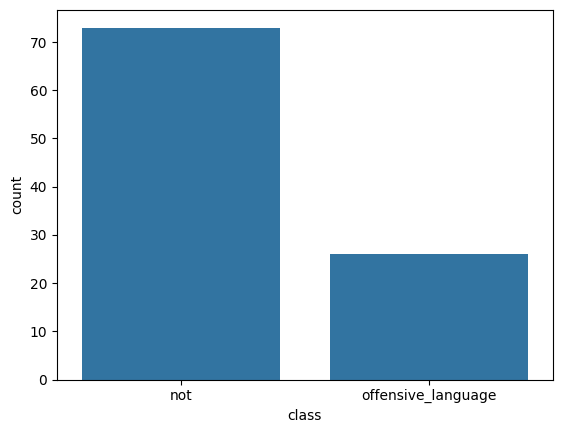

In [22]:
sns.countplot(x ='class', data = df)

Split the data into features (X) and target variable (y)

In [23]:
X = df['Tweet Text']
y = df['class']

In [24]:
X.shape

(99,)

In [25]:
y.shape

(99,)

In [26]:
#split our dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [27]:
X_train.head()

94    listening to my affirmations while i clean the...
30    i love love loveeeee being god n the creator o...
28                                  https t co v c e ac
89    im gonna affirm some things i want my sp to te...
5     repetition is so important cus its literally g...
Name: Tweet Text, dtype: object

In [28]:
y_train.head()

94                   not
30                   not
28                   not
89                   not
5     offensive_language
Name: class, dtype: object

In [29]:
X_train.shape

(69,)

In [30]:
y_train.shape

(69,)

feature extraction

In [31]:
vectorizer = TfidfVectorizer(stop_words='english') #converting a collection of raw documents (text) into a matrix of TF-IDF features.
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

## Solve unbalancing problem.

In [32]:
from imblearn.over_sampling import RandomOverSampler

# Initialize the RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Resample the data
X_train_balanced, y_train_balanced = ros.fit_resample(X_train_vectorized, y_train)


In [33]:
X_train_balanced_df = pd.DataFrame(X_train_balanced)
y_train_balanced_df = pd.DataFrame(y_train_balanced)

In [34]:
y_train_balanced_df.value_counts()

class             
not                   49
offensive_language    49
dtype: int64

## Hyperparameter tuning using GridSearchCV and cross validation

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid
param_grid = {
    'n_neighbors': range(1, 22),  # Testing k values from 1 to 20
    'weights': ['uniform', 'distance'],  # Testing different weight options
    'p': [1, 2]  # Testing Manhattan (p=1) and Euclidean (p=2) distances
}

# Create  KNN classifier
knn = KNeighborsClassifier()

# Create GridSearchCV
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the grid search to Our data
grid_search.fit(X_train_balanced, y_train_balanced)

# TO Get Our best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)


Best Parameters: {'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}
Best Score: 0.96


In [ ]:
# Define the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 9]  # Modify the range
}

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5)  # Modify the number of folds for cross-validation

# Fit the GridSearchCV object to our data
grid_search.fit(X_train_balanced, y_train_balanced)

# Get the best parameters found by GridSearchCV
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Get the best estimator model
best_model = grid_search.best_estimator_

# Use the best model for prediction
y_pred = best_model.predict(X_test_vectorized)


Best Parameters: {'criterion': 'entropy', 'max_depth': 9}


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

# Create the SVM classifier
svm = SVC()

# Create GridSearchCV
grid_search = GridSearchCV(svm, param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to our data
grid_search.fit(X_train_balanced, y_train_balanced)

# Best parameters found
print("Best parameters: ", grid_search.best_params_)



Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters:  {'C': 1, 'gamma': 1, 'kernel': 'rbf'}


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Example
#parameter grid for logistic regression
param_grid = {
    'penalty': ['l1', 'l2'],  # Regularization type
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
}

# Create a logistic regression model
logreg = LogisticRegression(solver='liblinear')

# Perform GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=logreg, param_grid=param_grid, cv=5)

# Fit the grid search to our data
grid_search.fit(X_train_balanced, y_train_balanced)

# Get the best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best Parameters: {'C': 10, 'penalty': 'l1'}


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

# Define the parameter grid for GridSearchCV
param_grid = {
    'alpha': [0.1, 0.5, 1.0]  # Example values for alpha
}

# Create an instance of the Naive Bayes classifier
nb_model = MultinomialNB()

# Perform grid search using the parameter grid and cross-validation
grid_search = GridSearchCV(estimator=nb_model, param_grid=param_grid, cv=5, n_jobs=-1)

# Assuming 'X_train_balanced' contains the resampled training data
# Assuming 'y_train_balanced' contains the true labels for the resampled training data

# Fit the grid search to the resampled training data
grid_search.fit(X_train_balanced, y_train_balanced)

# Get the best parameters and best score from the grid search
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)


Best Parameters: {'alpha': 0.1}
Best Score: 0.7957894736842106


In [ ]:
#RF(random forest)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']

} # Example parameter grid for KNN neighbors
rf_classifier=RandomForestClassifier()
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5)  # cv=5 for 5-fold CV

# Fit the grid search to your data
grid_search.fit(X_train_vectorized, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

#Best Parameters:  {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': entropy}

Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}


## Our Machine Learning Models !

## Performance Evaluation and Visualization


In [35]:
# Define Models
Models = [
    ('SVM', SVC(kernel='rbf', gamma=1, C=0.001)),
    ('Decision Tree', DecisionTreeClassifier(criterion= 'entropy', max_depth= 3, min_samples_leaf = 1, min_samples_split= 2)),
    ('Naive Bayes', MultinomialNB(alpha=1)),
    ('Logistic Regression', LogisticRegression(C=2, solver='liblinear', penalty='l1', random_state=42)),
    ('KNN', KNeighborsClassifier(n_neighbors=2, p= 1)),
    ('Random forest', RandomForestClassifier(criterion='gini', max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 50))
]
# Iterate through Models
for clf_name, clf in Models:
    # Fit the classifier
    clf.fit(X_train_balanced, y_train_balanced)

    # Predict on test data
    y_test_predict = clf.predict(X_test_vectorized)

    # Calculate test accuracy
    test_accuracy = accuracy_score(y_test, y_test_predict)

    # Predict on training data
    y_train_predict = clf.predict(X_train_balanced)

    # Calculate training accuracy
    train_accuracy = accuracy_score(y_train_balanced, y_train_predict)

    # Print accuracies
    print(f"Training Accuracy for {clf_name}: {train_accuracy}")
    print(f"Test Accuracy for {clf_name}: {test_accuracy}")

Training Accuracy for SVM: 0.9591836734693877
Test Accuracy for SVM: 0.8
Training Accuracy for Decision Tree: 0.8367346938775511
Test Accuracy for Decision Tree: 0.7
Training Accuracy for Naive Bayes: 0.9795918367346939
Test Accuracy for Naive Bayes: 0.7
Training Accuracy for Logistic Regression: 0.8673469387755102
Test Accuracy for Logistic Regression: 0.7666666666666667
Training Accuracy for KNN: 0.9591836734693877
Test Accuracy for KNN: 0.8333333333333334
Training Accuracy for Random forest: 0.9897959183673469
Test Accuracy for Random forest: 0.8666666666666667


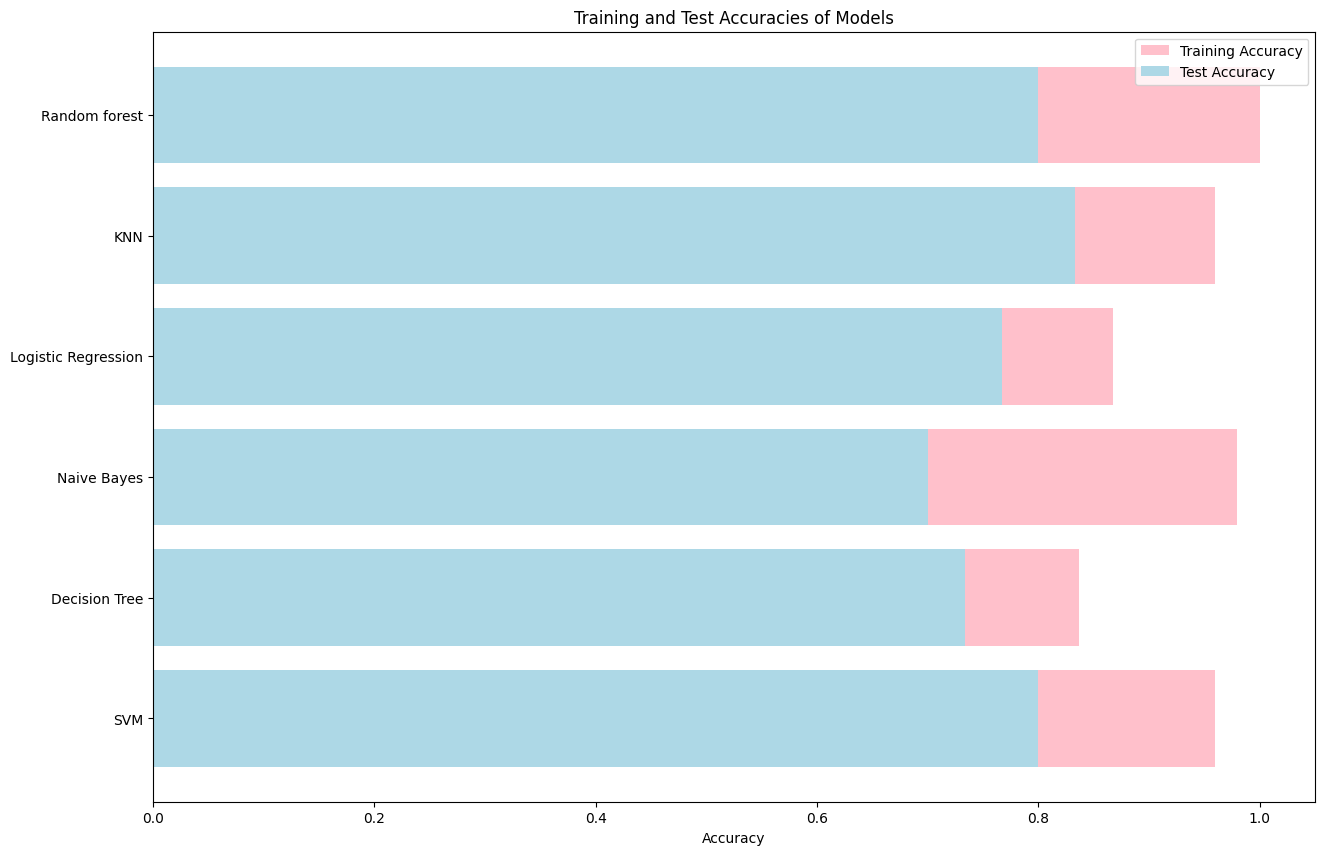

In [36]:
import matplotlib.pyplot as plt

# Two Lists to store accuracies
train_accuracies = []
test_accuracies = []

# Iterate through Models
for clf_name, clf in Models:
    # Fit the classifier
    clf.fit(X_train_balanced, y_train_balanced)

    # Predict on test data
    y_test_predict = clf.predict(X_test_vectorized)

    # Calculate test accuracy
    test_accuracy = accuracy_score(y_test, y_test_predict)

    # Predict on training data
    y_train_predict = clf.predict(X_train_balanced)

    # Calculate training accuracy
    train_accuracy = accuracy_score(y_train_balanced, y_train_predict)

    # Append accuracies to lists
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

# We created a par plot pink and baby blue colors
plt.figure(figsize=(15, 10))
plt.barh([f"{clf_name}" for clf_name, _ in Models], train_accuracies, color='pink', label='Training Accuracy')
plt.barh([f"{clf_name}" for clf_name, _ in Models], test_accuracies, color='lightblue', label='Test Accuracy')
plt.xlabel('Accuracy')
plt.title('Training and Test Accuracies of Models')
plt.legend()
plt.show()


Confusion_Matrix

Confusion Matrix for SVM:
[[24  0]
 [ 6  0]]


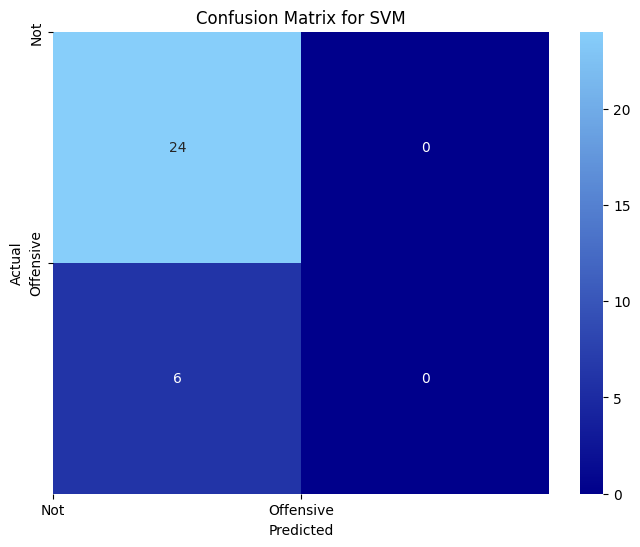

Confusion Matrix for Decision Tree:
[[20  4]
 [ 5  1]]


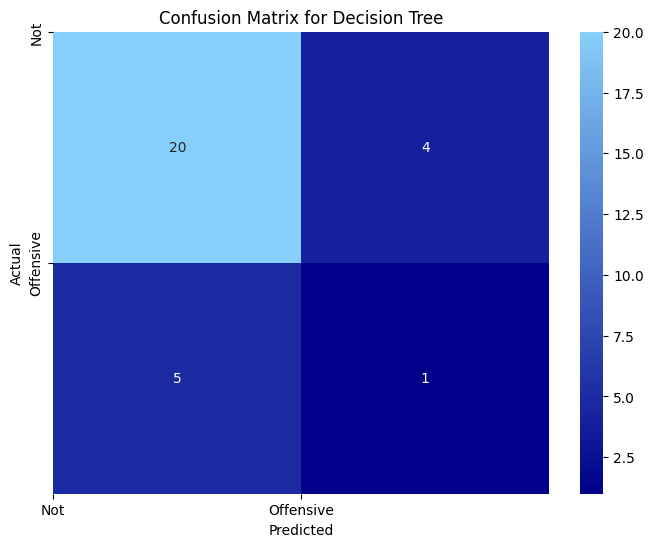

Confusion Matrix for Naive Bayes:
[[17  7]
 [ 2  4]]


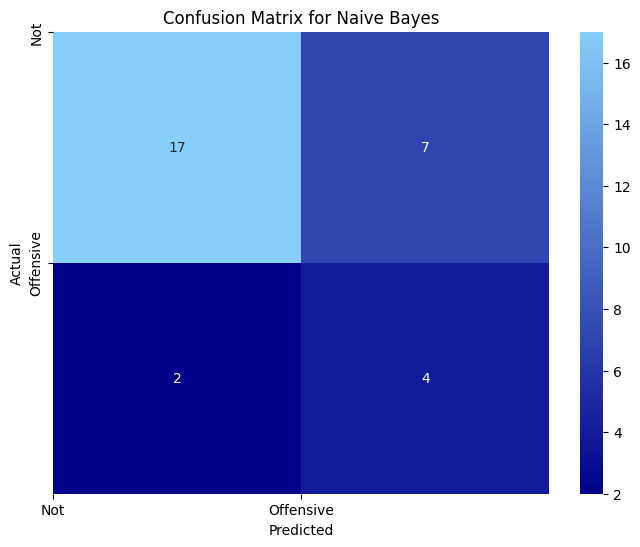

Confusion Matrix for Logistic Regression:
[[21  3]
 [ 4  2]]


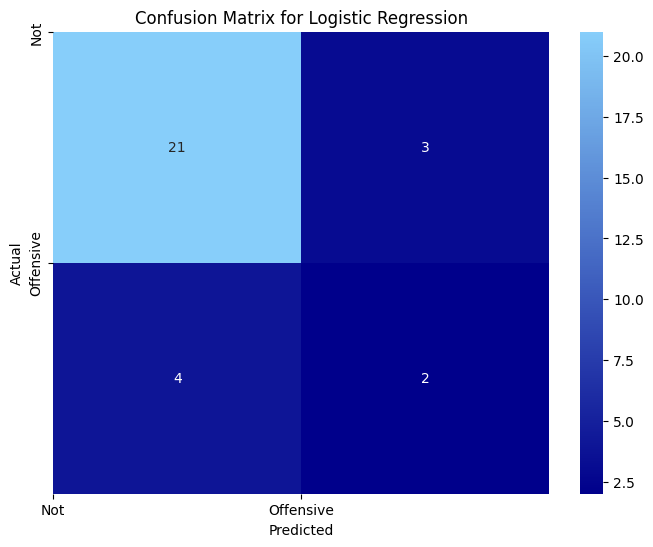

Confusion Matrix for KNN:
[[24  0]
 [ 5  1]]


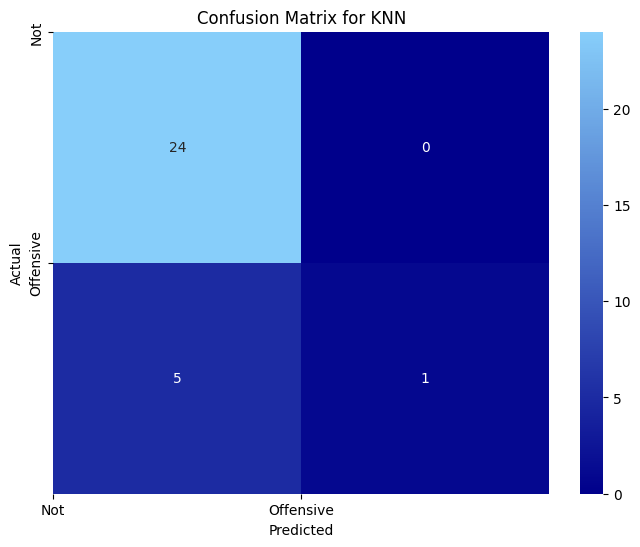

Confusion Matrix for Random forest:
[[22  2]
 [ 5  1]]


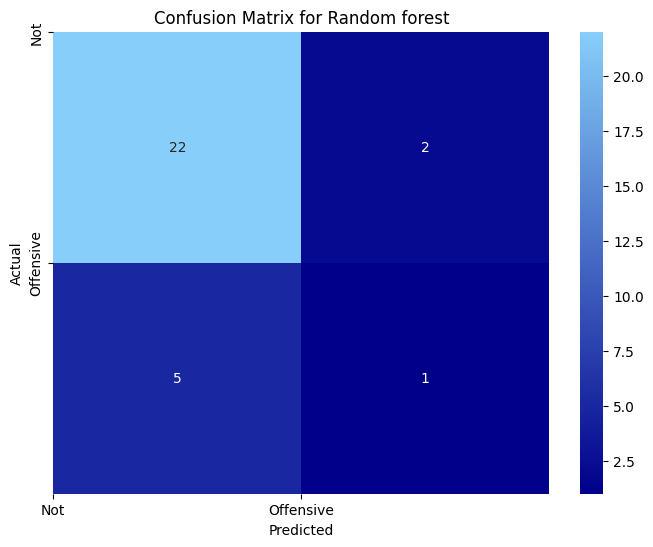

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.colors as mcolors

# To Make the Color Map Purple
#colors = [(1, 1, 1), (0.5, 0, 0.5)]  # White to purple gradient
dark_blue = '#00008B'  # Adjust this color code as needed
lighter_blue = '#87CEFA'
colors = [dark_blue, lighter_blue]
purple_cm = mcolors.LinearSegmentedColormap.from_list('dark_blue_to_light_blue', colors, N=256)


# Assuming that 'Models' is a list of tuples containing classifier names and corresponding classifier objects

for clf_name, clf in Models:
    # Fit the classifier
    clf.fit(X_train_balanced, y_train_balanced)

    # Predict on the test set
    y_pred = clf.predict(X_test_vectorized)

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Display confusion matrix details
    print(f"Confusion Matrix for {clf_name}:")
    print(cm)

    # Plot confusion matrix with the custom purple colormap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap=purple_cm, fmt='d')
    class_labels = ['Not', 'Offensive']
    plt.xticks(np.arange(len(class_labels)), class_labels)
    plt.yticks(np.arange(len(class_labels)), class_labels)
    plt.title(f'Confusion Matrix for {clf_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


Classification_Report

In [44]:
from sklearn.metrics import classification_report

# Iterate through the Models
for clf_name, clf in Models:
    # Fit the Models
    clf.fit(X_train_vectorized, y_train)

    # Predict on our test data
    y_test_predict = clf.predict(X_test_vectorized)

    # Generate classification report
    report = classification_report(y_test, y_test_predict)

    # Print classification report
    print(f"Classification Report for {clf_name}:")
    print(report)


Classification Report for SVM:
                    precision    recall  f1-score   support

               not       0.80      1.00      0.89        24
offensive_language       0.00      0.00      0.00         6

          accuracy                           0.80        30
         macro avg       0.40      0.50      0.44        30
      weighted avg       0.64      0.80      0.71        30

Classification Report for Decision Tree:
                    precision    recall  f1-score   support

               not       0.81      0.92      0.86        24
offensive_language       0.33      0.17      0.22         6

          accuracy                           0.77        30
         macro avg       0.57      0.54      0.54        30
      weighted avg       0.72      0.77      0.73        30

Classification Report for Naive Bayes:
                    precision    recall  f1-score   support

               not       0.80      1.00      0.89        24
offensive_language       0.00      0.00   

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif

## Ensemble

In [45]:
from sklearn.ensemble import VotingClassifier
# Create list of tuples containing the classifiers
estimators = Models

# Create Voting Classifier
voting_classifier = VotingClassifier(estimators)

# Fit the ensemble model
voting_classifier.fit(X_train_balanced, y_train_balanced)

# Predict on test data
y_test_predict = voting_classifier.predict(X_test_vectorized)

# Calculate test accuracy
test_accuracy = accuracy_score(y_test, y_test_predict)
print(f"Test Accuracy for Voting Classifier: {test_accuracy}")

Test Accuracy for Voting Classifier: 0.7666666666666667


In [ ]:
#Given input sentence
input_sentence = " Offensive is the most beautiful word "

#List of models
Models = [
   ('KNeighborsClassifier', KNeighborsClassifier(n_neighbors=8)),
   ('DecisionTreeClassifier', DecisionTreeClassifier(criterion="entropy", max_depth=9, random_state=42)),
   ('MultinomialNB', MultinomialNB()),
   ('LogisticRegression', LogisticRegression(random_state=42, C=1)),
   ('SVC', SVC(kernel='rbf', gamma=0.1, C=10)),
   ('Random forest', RandomForestClassifier(criterion='gini', max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 50))

]

#Iterate through models
for clf_name, clf in Models:
    #Vectorize the training data
    vectorizer = TfidfVectorizer()
    X_train_vectorized = vectorizer.fit_transform(X_train)

    #Train each classifier with the vectorized training data
    clf.fit(X_train_vectorized, y_train)

    #Vectorize the input sentence using the fitted vectorizer
    input_vector = vectorizer.transform([input_sentence])

    #Predict using the trained classifier model
    predicted_class = clf.predict(input_vector)

    #Display the predicted class for each model
    print(f"{clf_name} Predicted Class for '{input_sentence}': {predicted_class}")

SyntaxError: invalid syntax (<ipython-input-38-e37fba89d708>, line 15)